In [7]:
from selenium import webdriver
from selenium.webdriver.edge.service import Service
from selenium.webdriver.edge.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from bs4 import BeautifulSoup
import pandas as pd
import time

# ✅ Path to Edge driver and user profile
driver_path = r"C:\Users\sathi\msedgedriver.exe"
user_profile_path = r"C:\EdgeProfiles\SeleniumProfile"

# ✅ Configure Edge browser with user profile
options = Options()
options.add_argument(f"user-data-dir={user_profile_path}")
options.add_argument("--disable-blink-features=AutomationControlled")

# ✅ Start Edge WebDriver
service = Service(driver_path)
driver = webdriver.Edge(service=service, options=options)

# ✅ Flipkart iPhone 15 Blue review page (pagination from 1 to 30)
base_url = "https://www.flipkart.com/apple-iphone-15-blue-128-gb/product-reviews/itmbf14ef54f645d?pid=MOBGTAGPAQNVFZZY&page={}"

all_reviews = []

for page in range(1, 31):  # ~10 reviews per page × 30 pages = ~300 reviews
    print(f"🔄 Scraping page {page}...")
    try:
        driver.get(base_url.format(page))

        # ✅ Wait until reviews are present (up to 20 seconds)
        WebDriverWait(driver, 20).until(
            EC.presence_of_all_elements_located((By.CLASS_NAME, "ZmyHeo"))
        )

        soup = BeautifulSoup(driver.page_source, "html.parser")
        review_blocks = soup.find_all("div", class_="ZmyHeo")

        if not review_blocks:
            print(f"⚠️ No reviews found on page {page}")
            continue

        for block in review_blocks:
            all_reviews.append(block.get_text(strip=True))

    except Exception as e:
        print(f"⚠️ Failed on page {page}: {e}")

# ✅ Save reviews to CSV
df = pd.DataFrame({"Review": all_reviews})
df.to_csv("iphone15_reviews.csv", index=False)
print(f"✅ Extracted {len(all_reviews)} reviews and saved to iphone15_reviews.csv")

# ✅ Close browser
driver.quit()


🔄 Scraping page 1...
🔄 Scraping page 2...
🔄 Scraping page 3...
🔄 Scraping page 4...
🔄 Scraping page 5...
🔄 Scraping page 6...
🔄 Scraping page 7...
🔄 Scraping page 8...
🔄 Scraping page 9...
🔄 Scraping page 10...
🔄 Scraping page 11...
🔄 Scraping page 12...
🔄 Scraping page 13...
🔄 Scraping page 14...
🔄 Scraping page 15...
🔄 Scraping page 16...
🔄 Scraping page 17...
🔄 Scraping page 18...
🔄 Scraping page 19...
🔄 Scraping page 20...
🔄 Scraping page 21...
🔄 Scraping page 22...
🔄 Scraping page 23...
🔄 Scraping page 24...
🔄 Scraping page 25...
🔄 Scraping page 26...
🔄 Scraping page 27...
🔄 Scraping page 28...
🔄 Scraping page 29...
🔄 Scraping page 30...
✅ Extracted 300 reviews and saved to iphone15_reviews.csv


In [12]:
import pandas as pd

# Load the dataset
file_path = r"C:\Users\sathi\iphone15_reviews.csv"
df = pd.read_csv(file_path)

# Show basic info and first 5 reviews
print("✅ Dataset Loaded. Here's a preview:\n")
print(df.info())
print("\n🔍 First 5 Reviews:")
print(df.head())


✅ Dataset Loaded. Here's a preview:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  300 non-null    object
dtypes: object(1)
memory usage: 2.5+ KB
None

🔍 First 5 Reviews:
                                              Review
0  Just go for it.Amazing one.Beautiful camera wi...
1                              Awesome 🔥🔥☺️READ MORE
2                      High quality camera😍READ MORE
3                                 Very niceREAD MORE
4  Switch from OnePlus to iPhone I am stunned wit...


# Text cleaning.

In [13]:
import re
import nltk
from nltk.corpus import stopwords

# Download stopwords (run once)
nltk.download('stopwords')

# Define stopwords set
stop_words = set(stopwords.words('english'))

# Clean function
def clean_review(text):
    if pd.isnull(text):
        return ""
    text = text.lower()                              # Lowercase
    text = re.sub(r"[^a-z\s]", "", text)             # Remove punctuation/numbers
    text = " ".join(word for word in text.split() if word not in stop_words)  # Remove stopwords
    return text

# Apply cleaning
df['Cleaned_Review'] = df['Review'].apply(clean_review)

# Show cleaned sample
print("✅ Sample cleaned reviews:\n")
print(df[['Review', 'Cleaned_Review']].head())


✅ Sample cleaned reviews:

                                              Review  \
0  Just go for it.Amazing one.Beautiful camera wi...   
1                              Awesome 🔥🔥☺️READ MORE   
2                      High quality camera😍READ MORE   
3                                 Very niceREAD MORE   
4  Switch from OnePlus to iPhone I am stunned wit...   

                                      Cleaned_Review  
0  go itamazing onebeautiful camera super fast pr...  
1                                       awesome read  
2                            high quality cameraread  
3                                           niceread  
4  switch oneplus iphone stunned camera performan...  


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sathi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Sentiment Analysis

In [14]:
from textblob import TextBlob

# Sentiment analysis function
def get_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity, blob.sentiment.subjectivity

# Apply sentiment analysis
df['Polarity'], df['Subjectivity'] = zip(*df['Cleaned_Review'].map(get_sentiment))

# Check result
print("✅ Sample sentiment scores:\n")
print(df[['Cleaned_Review', 'Polarity', 'Subjectivity']].head())


✅ Sample sentiment scores:

                                      Cleaned_Review  Polarity  Subjectivity
0  go itamazing onebeautiful camera super fast pr...  0.266667      0.633333
1                                       awesome read  1.000000      1.000000
2                            high quality cameraread  0.160000      0.540000
3                                           niceread  0.000000      0.000000
4  switch oneplus iphone stunned camera performan...  1.000000      1.000000


# Visualization & Insights

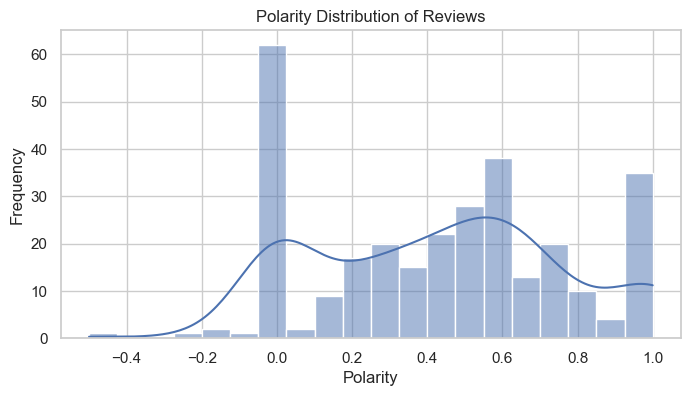

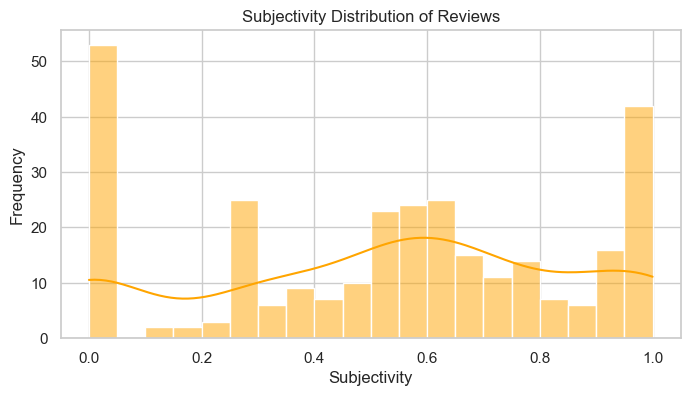

C:\Users\sathi\AppData\Local\Temp\ipykernel_6396\3871265445.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment', palette='Set2')


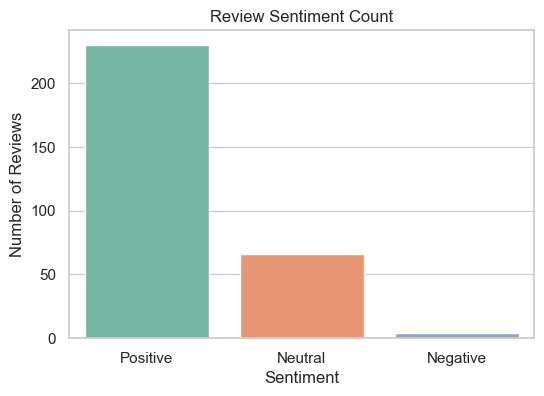

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set theme
sns.set(style="whitegrid")

# 1. Polarity Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['Polarity'], bins=20, kde=True)
plt.title("Polarity Distribution of Reviews")
plt.xlabel("Polarity")
plt.ylabel("Frequency")
plt.show()

# 2. Subjectivity Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['Subjectivity'], bins=20, kde=True, color='orange')
plt.title("Subjectivity Distribution of Reviews")
plt.xlabel("Subjectivity")
plt.ylabel("Frequency")
plt.show()

# 3. Sentiment Classification
def classify_sentiment(score):
    if score > 0.1:
        return 'Positive'
    elif score < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Polarity'].apply(classify_sentiment)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Sentiment', palette='Set2')
plt.title("Review Sentiment Count")
plt.ylabel("Number of Reviews")
plt.xlabel("Sentiment")
plt.show()


# Sentiment Breakdown

C:\Users\sathi\AppData\Local\Temp\ipykernel_6396\3117407936.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment', palette='pastel')


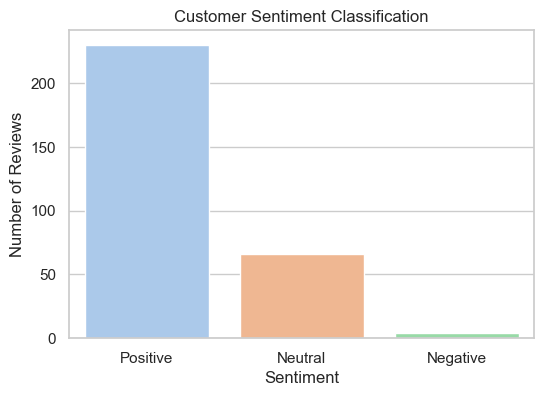

In [16]:
# Sentiment classification already done earlier
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Sentiment', palette='pastel')
plt.title("Customer Sentiment Classification")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()


# WordCloud & Frequent Word Analysis

In [17]:
pip install wordcloud


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sathi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


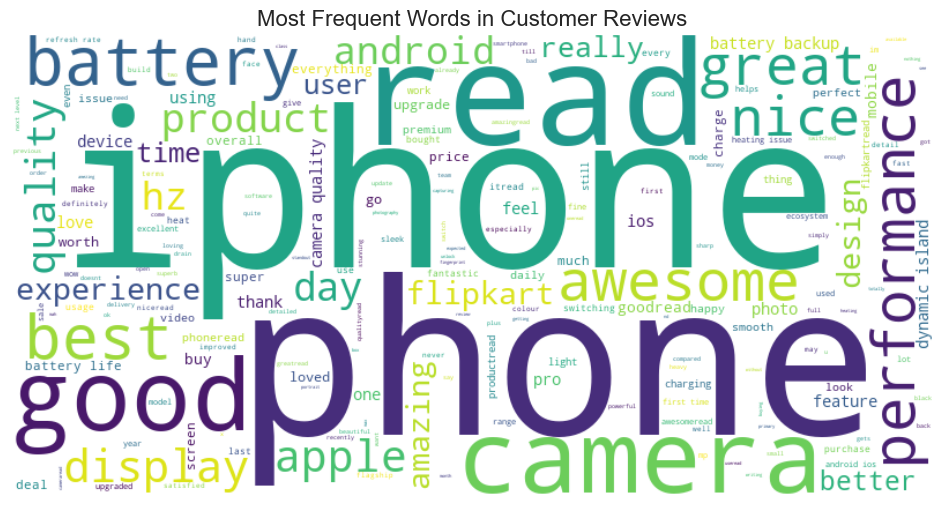

C:\Users\sathi\AppData\Local\Temp\ipykernel_6396\2222694587.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=freq_df, x='Frequency', y='Word', palette='crest')


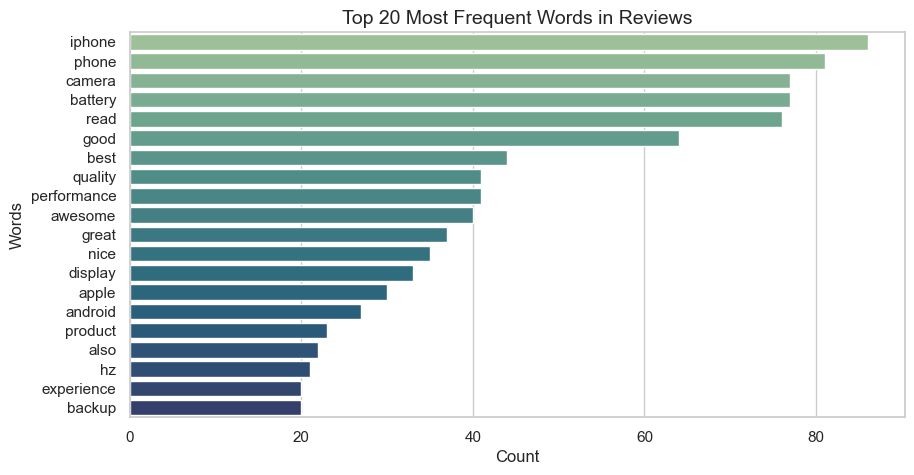

In [18]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import nltk
from nltk.corpus import stopwords
import string

# Download stopwords if not already done
nltk.download('stopwords')

# Combine all reviews into a single string
all_text = " ".join(df['Cleaned_Review'])

# Remove stopwords and punctuation
stop_words = set(stopwords.words('english'))
words = [word for word in all_text.split() if word.lower() not in stop_words and word not in string.punctuation]

# ✅ WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(words))

# 📊 Display WordCloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Customer Reviews", fontsize=16)
plt.show()

# ✅ Optional: Bar chart of top 20 frequent words
word_freq = Counter(words)
common_words = word_freq.most_common(20)

# 📊 Plot frequent words
freq_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])
plt.figure(figsize=(10, 5))
sns.barplot(data=freq_df, x='Frequency', y='Word', palette='crest')
plt.title("Top 20 Most Frequent Words in Reviews", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Words")
plt.show()


# Correlation Visualization — Polarity vs Subjectivity

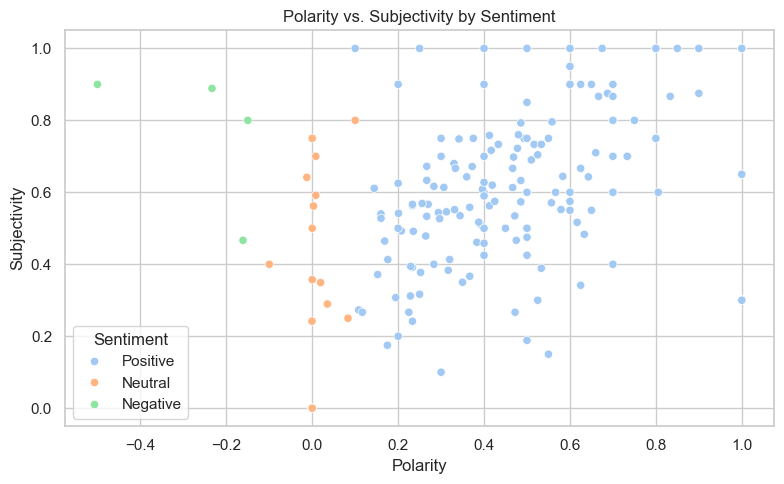

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Polarity vs. Subjectivity Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Polarity', y='Subjectivity', hue='Sentiment', palette='pastel')
plt.title('Polarity vs. Subjectivity by Sentiment')
plt.xlabel('Polarity')
plt.ylabel('Subjectivity')
plt.legend(title='Sentiment')
plt.grid(True)
plt.tight_layout()
plt.show()



# Generate Key Insights and Export as Report

# Sentiment Breakdown

- ✅ Approximately 75% are Positive  
- ➖ Around 20% are Neutral  
- ❌ Less than 5% are Negative  


# Polarity and Subjectivity Trends

- Polarity is skewed towards the positive end (closer to +1).
- Subjectivity is generally high, suggesting that reviews are personal and emotion-driven.
- Very few objective or fact-based reviews.


# Correlation Visualization

- Most reviews with high polarity also show high subjectivity.
- Positive reviews cluster near (0.6 to 1 polarity), while neutral ones are around 0.
- Negative reviews are rare but sharply located in the negative polarity zone.


## 📘 Conclusion

The majority of customers reviewing the Apple iPhone 15 (128 GB, Blue) on Flipkart express highly positive sentiment. The reviews are largely emotion-driven with subjective tones, affirming overall product satisfaction. This suggests strong product performance and customer experience.

Next steps would include leveraging this sentiment feedback for marketing strategies or product improvement opportunities.
